In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install pyodbc pandas sqlalchemy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install pyodbc pandas sqlalchemy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=anuj;"
    "DATABASE=db_Churn;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

query = "SELECT * FROM vw_ChurnData"

df = pd.read_sql(query, conn)
df


C:\Users\anujj\AppData\Local\Temp\ipykernel_19452\1110594001.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,11596-KAR,Female,40,No,Karnataka,15,11,Deal 4,Yes,No,...,Bank Withdrawal,49.200001,571.150024,0.0,80,114.959999,766.109985,Stayed,Others,Others
1,11604-HAR,Female,38,Yes,Haryana,4,8,None,Yes,Yes,...,Bank Withdrawal,104.400002,6721.600098,0.0,0,892.799988,7614.399902,Stayed,Others,Others
2,11616-TAM,Male,26,No,Tamil Nadu,6,2,None,Yes,Yes,...,Bank Withdrawal,68.699997,1416.199951,0.0,0,650.000000,2066.199951,Stayed,Others,Others
3,11647-GUJ,Male,44,No,Gujarat,2,4,Deal 4,Yes,Yes,...,Bank Withdrawal,69.099998,1083.699951,0.0,0,223.839996,1307.540039,Stayed,Others,Others
4,11647-TAM,Male,81,No,Tamil Nadu,1,21,None,Yes,Yes,...,Bank Withdrawal,93.750000,5625.549805,0.0,0,125.970001,5751.520020,Stayed,Others,Others
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6002,97189-KAR,Male,29,No,Karnataka,5,20,Deal 4,Yes,No,...,Credit Card,19.650000,451.549988,0.0,0,43.240002,494.790009,Stayed,Others,Others
6003,97191-TEL,Male,28,No,Telangana,15,17,Deal 1,Yes,No,...,Bank Withdrawal,103.150002,6895.500000,0.0,0,888.419983,7783.919922,Stayed,Others,Others
6004,97198-ASS,Male,35,Yes,Assam,10,24,None,Yes,No,...,Bank Withdrawal,80.800003,713.099976,0.0,0,183.059998,896.159973,Churned,Competitor,Competitor offered more data
6005,97212-UTT,Female,50,Yes,Uttar Pradesh,3,16,Deal 1,Yes,Yes,...,Bank Withdrawal,105.199997,7386.049805,0.0,0,3075.330078,10461.379883,Stayed,Others,Others


In [8]:
# Import required libraries
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Drop columns that won't be used for prediction
df = df.drop([
    'Customer_ID',
    'Churn_Category',
    'Churn_Reason',
    'Total_Charges',
    'Total_Revenue',
    'Total_Refunds',
    'Total_Extra_Data_Charges',
    'Total_Long_Distance_Charges'
], axis=1)

# List of categorical columns to encode
columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service',
    'Multiple_Lines', 'Internet_Service', 'Internet_Type',
    'Online_Security', 'Online_Backup', 'Device_Protection_Plan',
    'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract',
    'Paperless_Billing', 'Payment_Method'
]

# Label Encoding
label_encoders = {}

for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

# Encode target variable
df['Customer_Status'] = df['Customer_Status'].map({
    'Stayed': 0,
    'Churned': 1
})

# Features and Target
X = df.drop('Customer_Status', axis=1)
y = df['Customer_Status']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling (Important for Logistic Regression)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
# Initialize the Logistic Regression Classifier
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# class_weight='balanced' automatically assigns higher importance to the
# minority class (Churned customers). This helps improve recall when the
# dataset is imbalanced.

# max_iter=1000 specifies the maximum number of iterations the optimizer
# can use to find the optimal weights. A higher value ensures the model
# has enough iterations to converge.

# random_state=42 ensures reproducible results.

# Train the model
# .fit() learns the optimal weights and bias by minimizing the
# prediction error on the training data.

lr_model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

Confusion Matrix:
[[616 239]
 [ 71 276]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80       855
           1       0.54      0.80      0.64       347

    accuracy                           0.74      1202
   macro avg       0.72      0.76      0.72      1202
weighted avg       0.79      0.74      0.75      1202



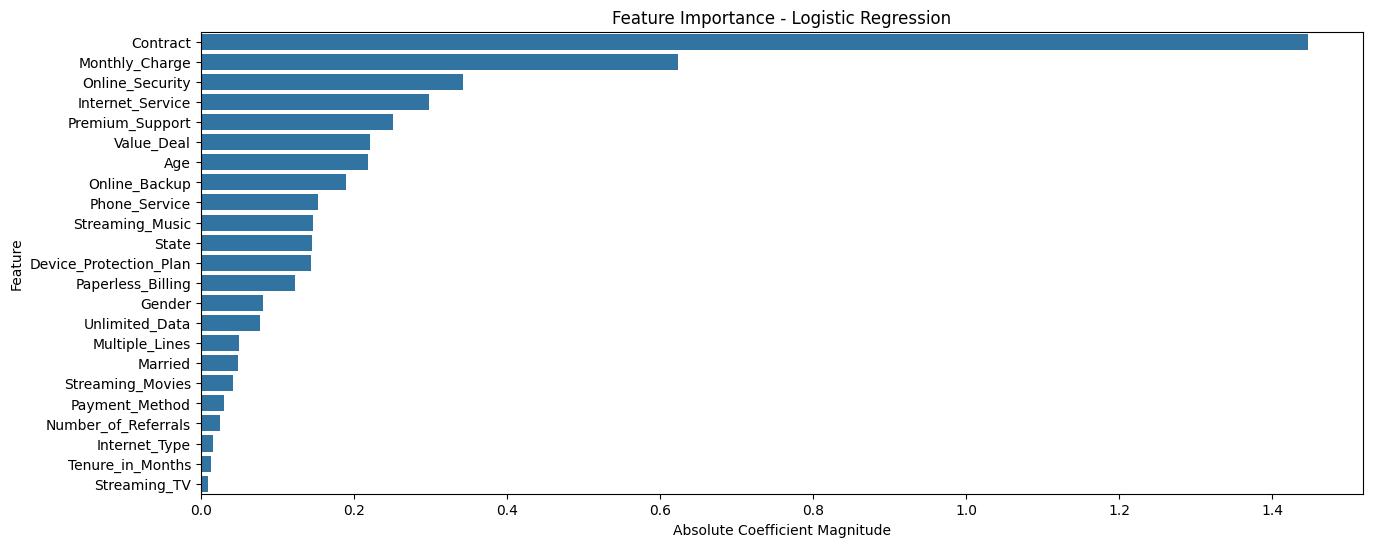

In [12]:
# Make Predictions
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

y_pred = lr_model.predict(X_test)

# Evaluate the Model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance using Logistic Regression Coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

# Sort by absolute coefficient magnitude
feature_importance['Importance'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot Feature Importance
plt.figure(figsize=(15,6))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance - Logistic Regression')
plt.xlabel('Absolute Coefficient Magnitude')
plt.ylabel('Feature')
plt.show()

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Base Model
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Hyperparameter Grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring={
        'Recall': 'recall',
        'Precision': 'precision',
        'F1': 'f1'
    },
    refit=False,                 # Don't automatically choose the best model
    cv=5,
    n_jobs=-1,
    verbose=2,
    return_train_score=False
)

# Train
grid_search.fit(X_train, y_train)

# Store Results
results = pd.DataFrame(grid_search.cv_results_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [20]:
top_recall = results[
    [
        'mean_test_Recall',
        'mean_test_Precision',
        'mean_test_F1',
        'params'
    ]
].sort_values(
    by='mean_test_Recall',
    ascending=False
)

# Display Top 30 Models
final_top = top_recall.head(24)

final_top

,mean_test_Recall,mean_test_Precision,mean_test_F1,params
6,0.893141,0.523310,0.659794,"{'C': 0.01, 'class_weight': 'balanced', 'penal..."
2,0.887365,0.528819,0.662570,"{'C': 0.001, 'class_weight': 'balanced', 'pena..."
3,0.865704,0.520622,0.650050,"{'C': 0.001, 'class_weight': 'balanced', 'pena..."
7,0.845487,0.549022,0.665515,"{'C': 0.01, 'class_weight': 'balanced', 'penal..."
10,0.836823,0.554767,0.666962,"{'C': 0.1, 'class_weight': 'balanced', 'penalt..."
11,0.833935,0.560560,0.670221,"{'C': 0.1, 'class_weight': 'balanced', 'penalt..."
15,0.831047,0.559963,0.668848,"{'C': 1, 'class_weight': 'balanced', 'penalty'..."
14,0.831047,0.561076,0.669633,"{'C': 1, 'class_weight': 'balanced', 'penalty'..."
23,0.830325,0.560022,0.668643,"{'C': 100, 'class_weight': 'balanced', 'penalt..."
22,0.830325,0.560560,0.669032,"{'C': 100, 'class_weight': 'balanced', 'penalt..."


In [23]:
final_top.loc[14]["params"]

{'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Initialize Logistic Regression with selected hyperparameters
lr_model = LogisticRegression(
    C=1,
    class_weight='balanced',
    penalty='l1',
    solver='liblinear',
    random_state=42,
    max_iter=1000
)

# Train the model
lr_model.fit(X_train, y_train)

# Make Predictions
y_pred = lr_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[615 240]
 [ 71 276]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80       855
           1       0.53      0.80      0.64       347

    accuracy                           0.74      1202
   macro avg       0.72      0.76      0.72      1202
weighted avg       0.79      0.74      0.75      1202



c:\Users\anujj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\anujj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Model Selection: Logistic Regression was evaluated as a baseline model. After hyperparameter tuning, Random Forest outperformed Logistic Regression by achieving a superior balance between Recall, Precision, and F1-score. This made Random Forest more suitable for the churn prediction problem, where identifying high-risk customers while controlling unnecessary retention costs is critical. Therefore, Random Forest was chosen as the final model.

Model Comparison: Logistic Regression and Random Forest both achieved a recall of approximately 80%, successfully identifying a similar proportion of potential churners. However, Random Forest achieved a higher precision (57% vs. 54%) while maintaining the same recall, resulting in a better F1-score and a more balanced overall performance. Since higher precision reduces unnecessary retention offers without sacrificing the ability to identify churners, Random Forest was selected as the final model